# gemma4:e4b — evaluation

How well gemma4:e4b labels Data Management Plan text, checked against 10 documents a
person labeled by hand. Text extracted with lightonocr.

There are two versions of the score: **Path A** is the model's raw answer. **Path B**
is after a small automatic fix-up step runs. They're checked against two different
answer keys, so compare the scores between them, not the raw counts — see section 3.


## The pipeline

Four steps: read the PDF, label the text, turn it into a structured document, then run
a small fix-up step. **Path A** is scored right after labeling. **Path B** is scored
after the fix-up.


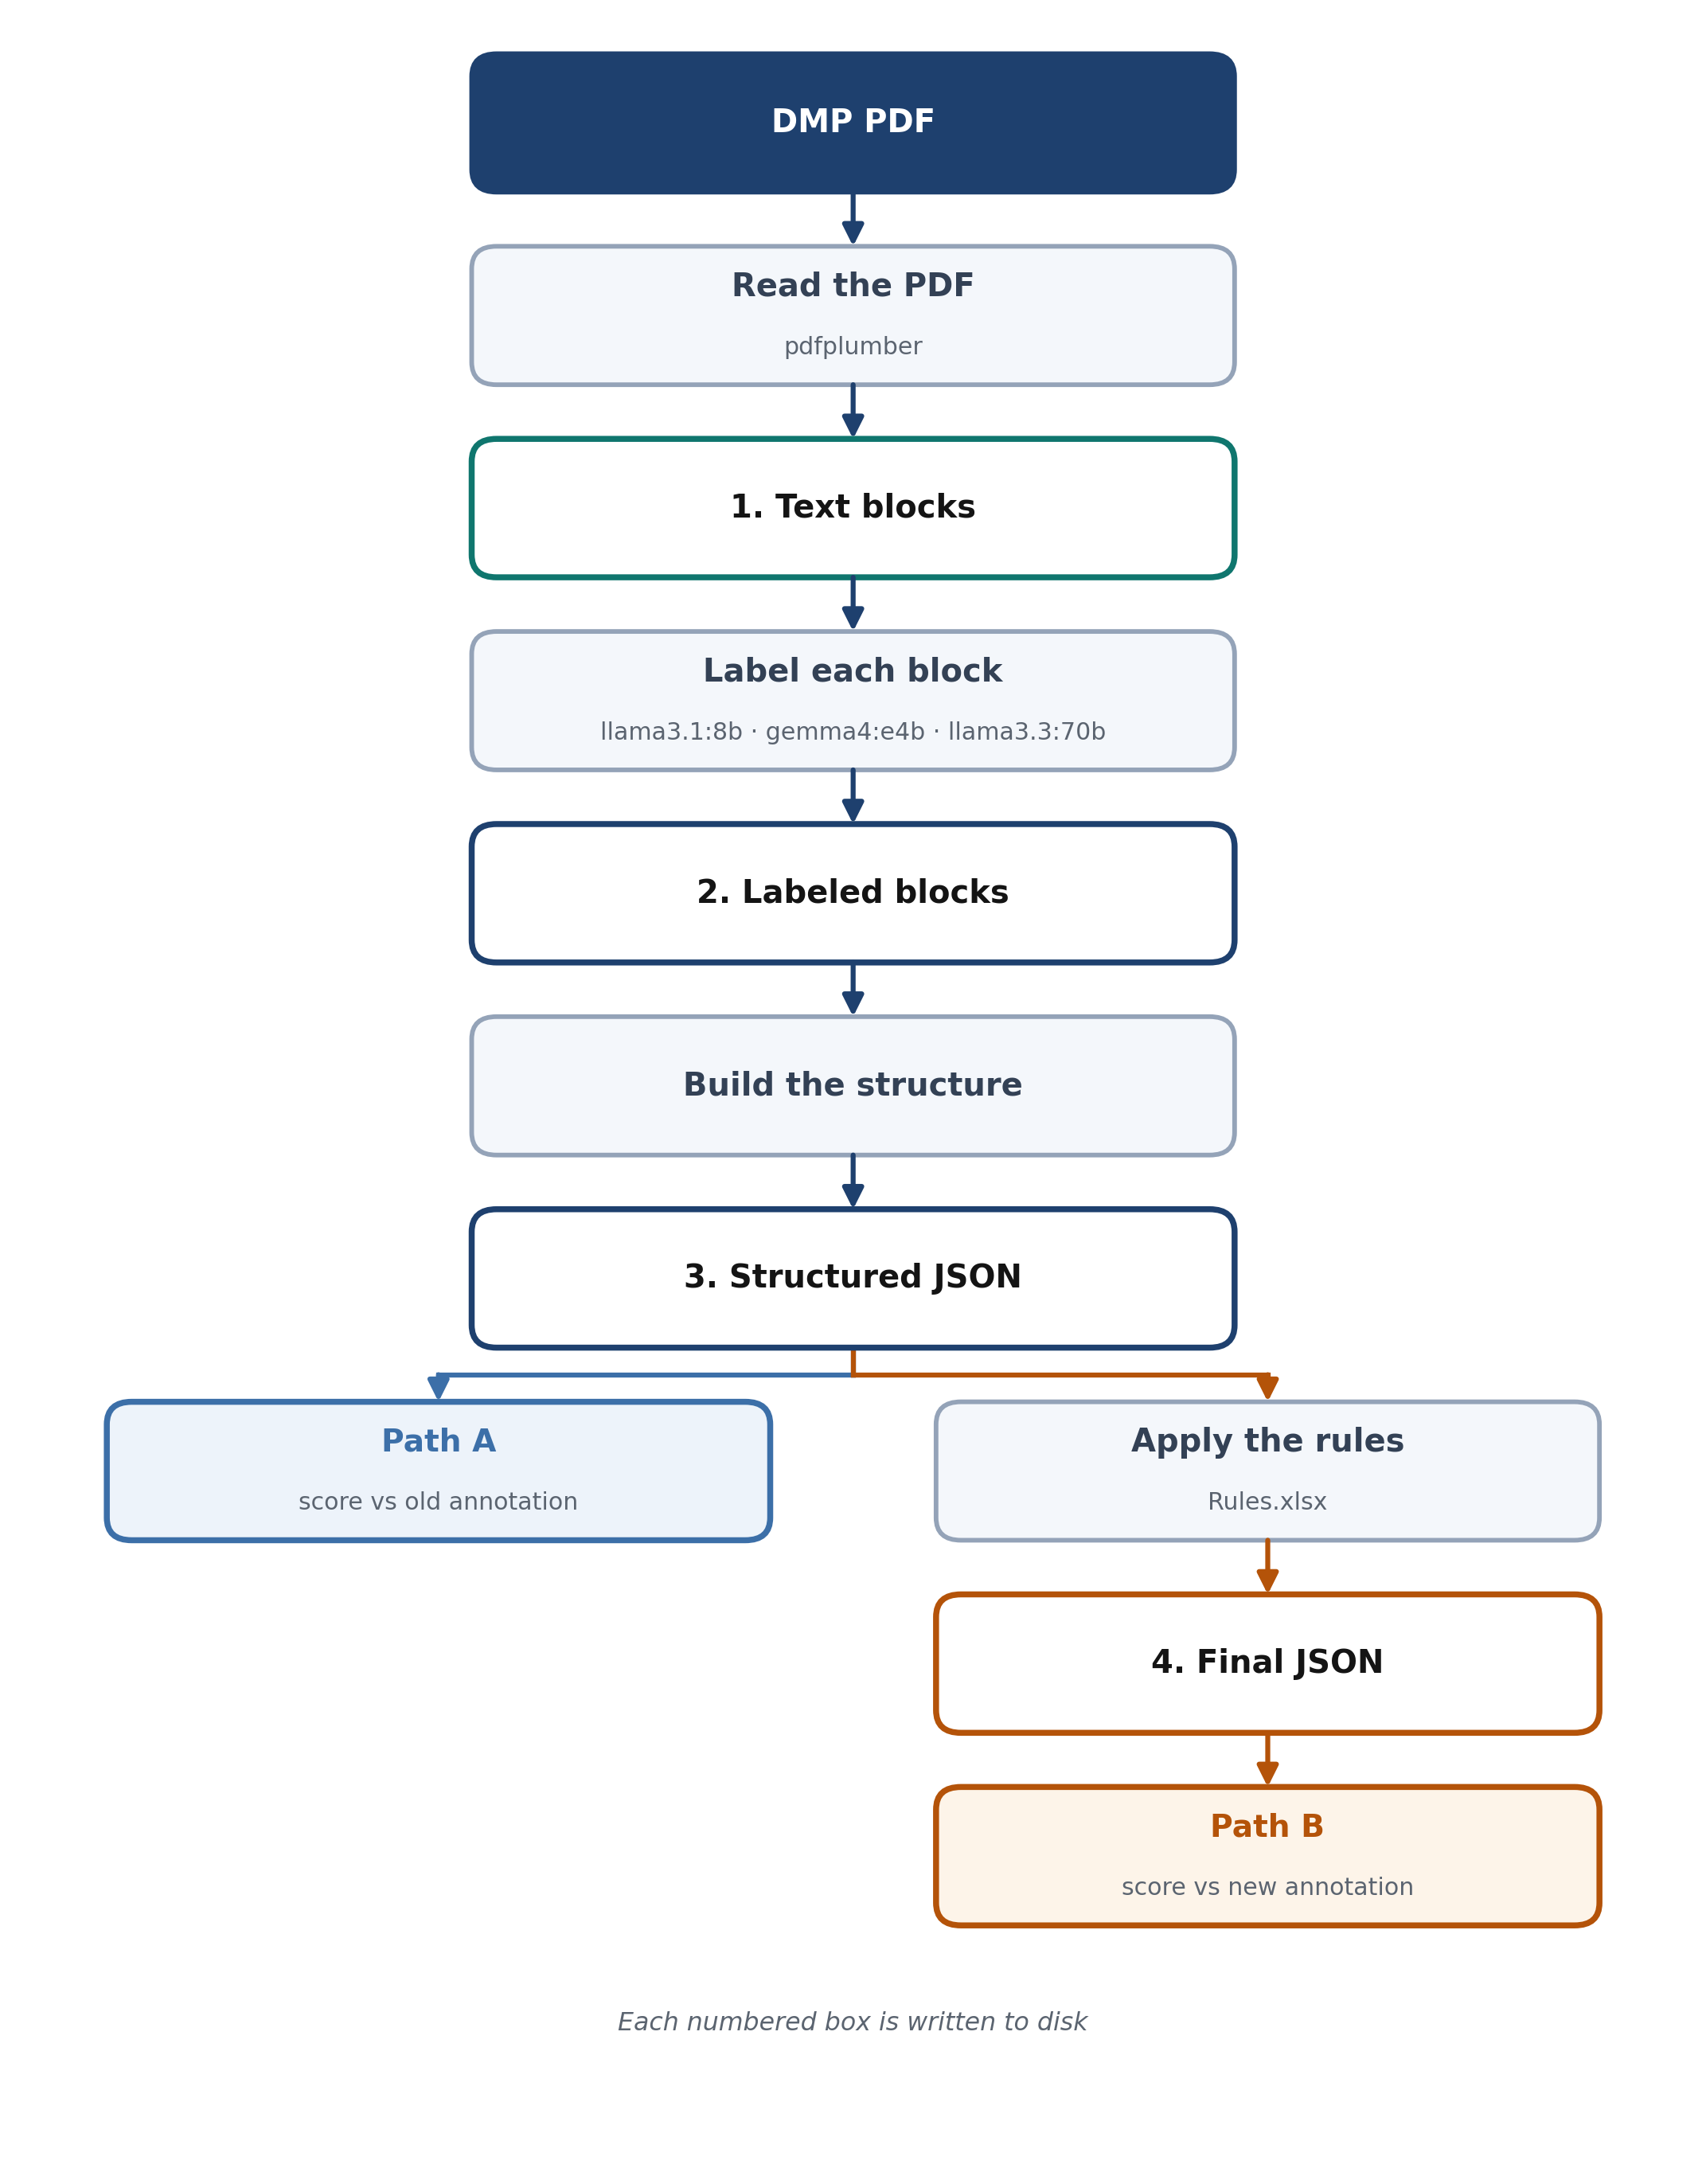

In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import Image

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

# The same flow README.md shows. Drawn with matplotlib rather than mermaid:
# GitHub renders mermaid in .md files but not inside .ipynb, and it does
# render image outputs — so this survives the trip to the repo.
DIAGRAM = Path('Report-doc/pipeline_simple.png')
if not DIAGRAM.exists():
    subprocess.run([sys.executable, 'scripts/build/make_pipeline_simple.py'],
                   check=True)

Image(str(DIAGRAM), width=700)


In [2]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, micro_prf1, compute_f1_rows, LABELS,
    _match_structured, extract_gold, resolve_old_gt_path,
)
from dmpbridge.evaluation.annotation_rules import (
    load_method_new, convert_tag_to_final, resolve_new_gt_path,
)

MODEL, TAG = 'gemma4:e4b', 'gemma4-e4b_lightonocr_whole_doc'
THRESHOLD = None   # None = the project default

# Reference categorical palette, slots 1-3 — the set validated for all pairs.
# One hue per metric, held constant across every chart and both paths.
PRECISION, RECALL, F1 = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})

# Path A — structured output vs the original annotation.
df_a, conf_a, err_a = load_method_old(TAG, exclude=[], threshold=THRESHOLD)

# Path B — rules applied, vs the revised annotation. Stage 4 is derived from
# stage 3, so build it if this tag has not been converted yet.
res_b = load_method_new(TAG, exclude=[], threshold=THRESHOLD)
if res_b[0] is None:
    convert_tag_to_final(TAG)
    res_b = load_method_new(TAG, exclude=[], threshold=THRESHOLD)
df_b, conf_b, err_b = res_b

PATHS = (('Path A', conf_a), ('Path B', conf_b))
print(f'{MODEL}')
print(f'  Path A: {len(df_a)} documents')
print(f'  Path B: {len(df_b)} documents')


gemma4:e4b
  Path A: 10 documents
  Path B: 10 documents


## 1. Metrics

Each predicted item is checked against the real one it should match:

| | |
|---|---|
| **TP** &nbsp;true positive | correct match |
| **FP** &nbsp;false positive | wrong label, or made up with no real match |
| **FN** &nbsp;false negative | a real item that got missed |

```
precision  =  TP / (TP + FP)
recall     =  TP / (TP + FN)
f1-score   =  2 * precision * recall / (precision + recall)
```

Precision drops when the model makes things up. Recall drops when it misses real
items. F1 is a mix of both, so it stays low unless both are good.


## 2. Classification report

Precision, recall, and F1 for each label, once per path. "Support" is how many real
items that label has — it differs between paths because they use different answer
keys, so compare the scores, not the raw counts.


In [3]:
pc_a = compute_f1_rows(conf_a).set_index('label')
pc_b = compute_f1_rows(conf_b).set_index('label')
m_a, m_b = micro_prf1(conf_a), micro_prf1(conf_b)


def show_report(name, per_class, m):
    """Print one path's report in the conventional layout."""
    print(name)
    print(f"{'':<22}{'precision':>10}{'recall':>9}{'f1-score':>10}{'support':>9}")
    print()
    for lab, r in per_class.iterrows():
        print(f"{lab:<22}{r['precision']:>10.3f}{r['recall']:>9.3f}"
              f"{r['f1']:>10.3f}{int(r['support']):>9}")
    print()
    total = int(per_class['support'].sum())
    print(f"{'micro avg':<22}{m['precision']:>10.3f}{m['recall']:>9.3f}"
          f"{m['f1']:>10.3f}{total:>9}")
    print(f"{'macro avg':<22}{per_class['precision'].mean():>10.3f}"
          f"{per_class['recall'].mean():>9.3f}{per_class['f1'].mean():>10.3f}"
          f"{total:>9}")
    w = per_class['support'] / per_class['support'].sum()
    print(f"{'weighted avg':<22}{(per_class['precision'] * w).sum():>10.3f}"
          f"{(per_class['recall'] * w).sum():>9.3f}{(per_class['f1'] * w).sum():>10.3f}"
          f"{total:>9}")


show_report('Path A', pc_a, m_a)
print()
print()
show_report('Path B', pc_b, m_b)


Path A
                       precision   recall  f1-score  support

title                      1.000    0.900     0.947       10
section.title              0.913    0.977     0.944       43
section.description        0.400    1.000     0.571        8
question.text              0.900    0.562     0.692       16
answer.text                0.867    0.709     0.780       55

micro avg                  0.823    0.811     0.817      132
macro avg                  0.816    0.830     0.787      132
weighted avg               0.868    0.811     0.823      132


Path B
                       precision   recall  f1-score  support

title                      1.000    0.900     0.947       10
section.title              0.917    0.978     0.946       45
section.description        0.400    1.000     0.571        8
question.text              0.911    0.732     0.812       56
answer.text                0.867    0.709     0.780       55

micro avg                  0.844    0.810     0.827      174
macr

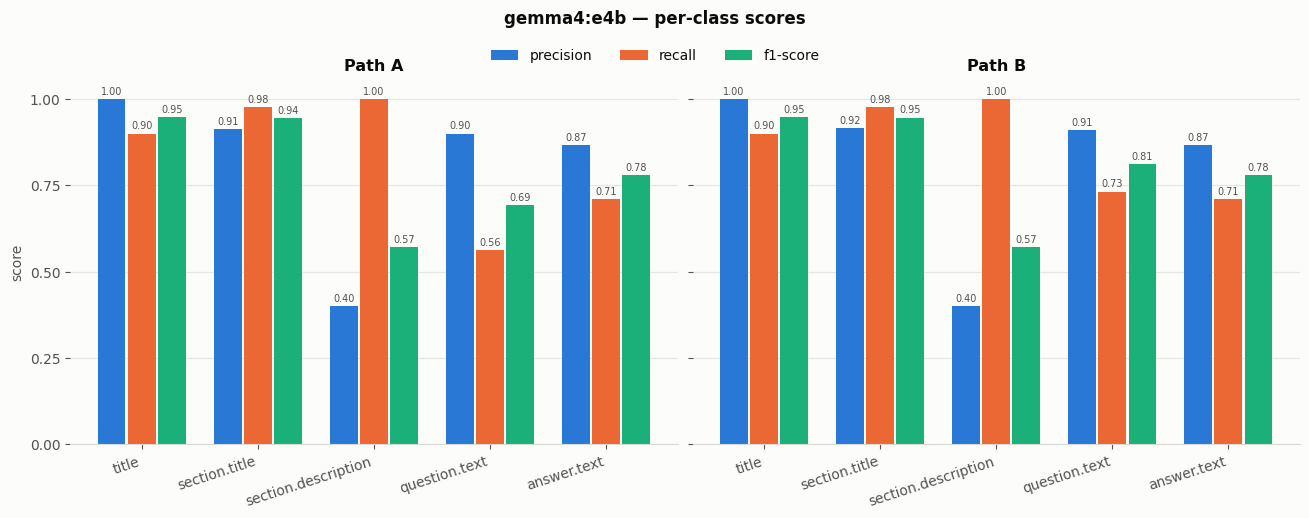

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharey=True)
w = 0.26

for ax, (title, per_class) in zip(axes, (('Path A', pc_a), ('Path B', pc_b))):
    x = np.arange(len(per_class))
    for k, (col, colour) in enumerate((('precision', PRECISION),
                                       ('recall', RECALL),
                                       ('f1', F1))):
        bars = ax.bar(x + (k - 1) * w, per_class[col], width=w - 0.02,
                      color=colour, label=col if col != 'f1' else 'f1-score')
        # Values sit above the bars: 15 bars per panel are too many to read
        # off the axis, which is left to do the comparing instead.
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7, color=MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(per_class.index, rotation=18, ha='right')
    ax.set_ylim(0, 1.06)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_title(title)
    ax.grid(axis='y', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('score')
plt.tight_layout()

# Legend and title are added after tight_layout, or it reserves no room for them.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc='upper center',
           bbox_to_anchor=(0.5, 1.00), borderaxespad=0)
fig.suptitle(f'{MODEL} — per-class scores', fontweight='bold', y=1.07)
plt.show()


## 3. Confusion matrix — % of each true class

Rows are the real label. Columns are what the model called it. The outlined boxes on
the diagonal are correct matches.

**Path A and Path B use different answer keys**, so the same label can have a very
different total count in each panel — that's expected, not an error.

**Each cell is a percentage of its row.** That keeps every row on the same scale no
matter how big or small the label is, and **the diagonal cell is that label's recall**.

**The last column, `(not labeled)`,** means the model produced nothing at all for that
real item.

One thing this chart can't show: items the model made up with no real match at all —
those show up in section 2's precision number instead.


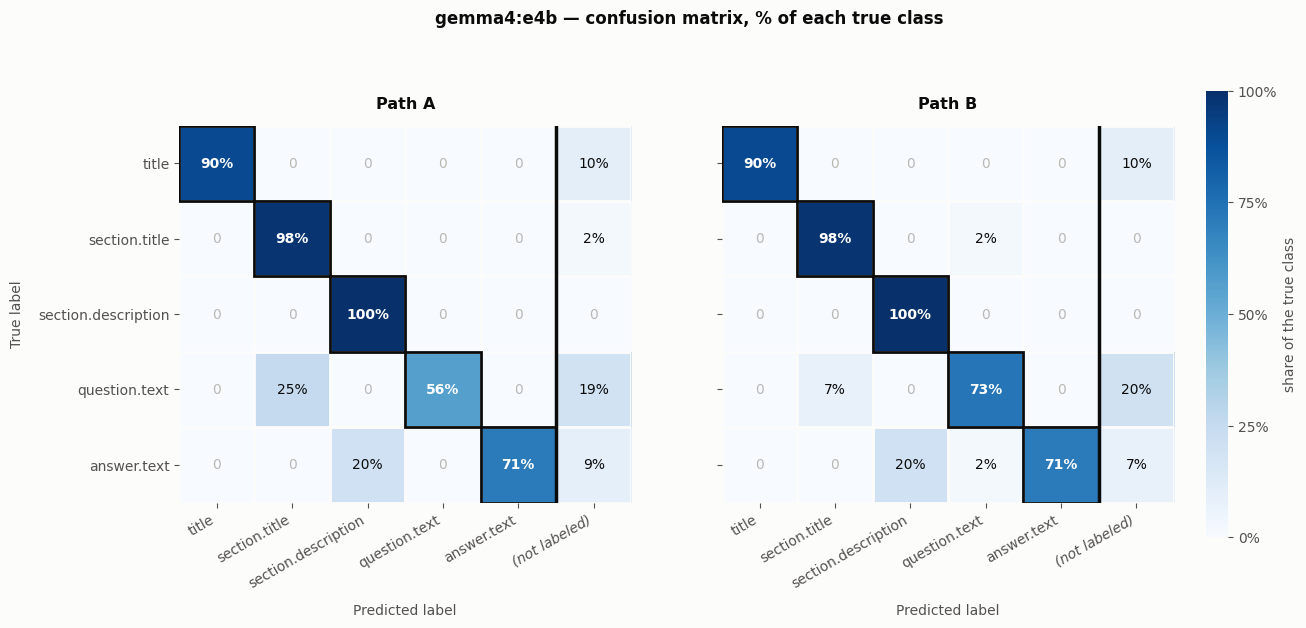

In [5]:
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']


def build_pct(conf):
    """Row-percentage matrix: cell (i, j) = share of true class i predicted
    as j, out of ALL real items of class i. The final column holds the ones
    never produced, so the diagonal is exactly recall and each row sums to 1."""
    pct = np.zeros((len(LABELS), len(KEYS)))
    for i, t in enumerate(LABELS):
        row_total = sum(conf.get(t, {}).values())
        for j, key in enumerate(KEYS):
            if row_total:
                pct[i, j] = conf.get(t, {}).get(key, 0) / row_total
    return pct


fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.8), sharey=True)

for ax, (title, conf) in zip(axes, PATHS):
    cm = build_pct(conf)
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(len(LABELS)):
        for j in range(len(KEYS)):
            v = cm[i, j]
            ax.text(j, i, f'{v:.0%}' if v else '0', ha='center', va='center',
                    fontsize=10, fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v > 0.55 else INK))

    ax.set_xticks(range(len(COLS)))
    ax.set_xticklabels(COLS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_title(title, pad=12)

    ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2)
    ax.tick_params(which='minor', length=0)

    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                   edgecolor=INK, linewidth=2.0, zorder=5))
    # the last column is not a label the model chose -- keep it set apart
    ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
    ax.get_xticklabels()[-1].set_style('italic')
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('True label', labelpad=10)
cbar = fig.colorbar(im, ax=axes, fraction=0.026, pad=0.03, label='share of the true class')
cbar.outline.set_visible(False)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
fig.suptitle(f'{MODEL} — confusion matrix, % of each true class', fontweight='bold', y=1.02)
plt.show()


### 3a. The same matrix, in raw counts

Same information as above, but as plain counts instead of percentages.


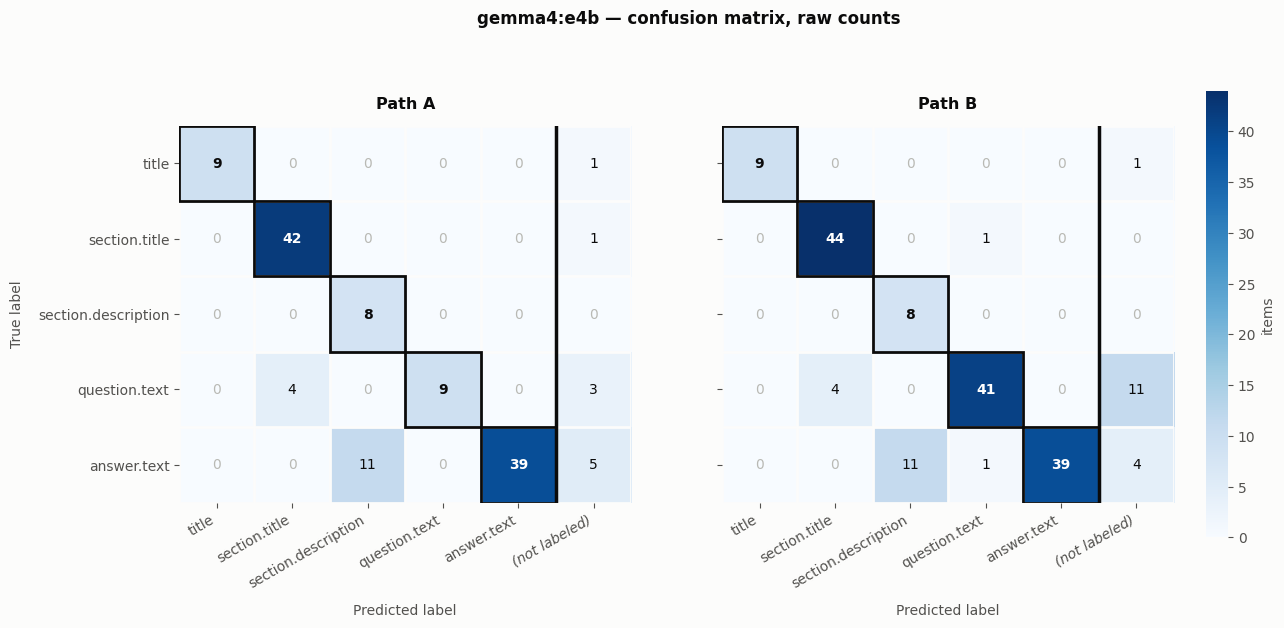

In [6]:
def build_counts(conf):
    counts = np.zeros((len(LABELS), len(KEYS)), dtype=int)
    for i, t in enumerate(LABELS):
        for j, key in enumerate(KEYS):
            counts[i, j] = conf.get(t, {}).get(key, 0)
    return counts


count_mats = [build_counts(conf) for _, conf in PATHS]
vmax = max(cm.max() for cm in count_mats)   # one scale, so both panels are comparable

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.8), sharey=True)

for ax, (title, _), cm in zip(axes, PATHS, count_mats):
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
    for i in range(len(LABELS)):
        for j in range(len(KEYS)):
            v = int(cm[i, j])
            ax.text(j, i, str(v) if v else '0', ha='center', va='center', fontsize=10,
                    fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v / vmax > 0.55 else INK))

    ax.set_xticks(range(len(COLS)))
    ax.set_xticklabels(COLS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_title(title, pad=12)

    ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2)
    ax.tick_params(which='minor', length=0)

    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                   edgecolor=INK, linewidth=2.0, zorder=5))
    ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
    ax.get_xticklabels()[-1].set_style('italic')
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('True label', labelpad=10)
cbar = fig.colorbar(im, ax=axes, fraction=0.026, pad=0.03, label='items')
cbar.outline.set_visible(False)
fig.suptitle(f'{MODEL} — confusion matrix, raw counts', fontweight='bold', y=1.02)
plt.show()


**Read a row** to see what happened to one real label. **Read a column** to see
everything the model called one label. **Comparing the two panels** shows what the
fix-up step changed.


### 3b. Every mismatch, with the actual text

**Path B only** — the final output. The matrix above only gives counts; this lists
every item that didn't match cleanly — wrong label, or missing entirely — with the
sample number and the real text.


In [7]:
pd.set_option('display.max_colwidth', None)


def matrix_detail_rows():
    """One row per Path B item that is NOT a clean diagonal match in the
    confusion matrix: either labeled as something other than its true class,
    or produced nothing at all ('(not labeled)'). Diagonal (correct) items
    are not listed here — this is only the cells the matrix flags as errors."""
    rows = []
    for n in range(1, 11):
        gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
        records, _ = _match_structured(P.final_path(TAG, n), gold,
                                       dedup_question_title=False, threshold=THRESHOLD)
        for r in records:
            if r['pred_text'] is None:
                rows.append({'sample': n, 'true label': r['gold_label'],
                             'predicted label': '(not labeled)', 'text': r['gold_text']})
            elif r['pred_label'] != r['gold_label']:
                rows.append({'sample': n, 'true label': r['gold_label'],
                             'predicted label': r['pred_label'], 'text': r['pred_text']})
    return pd.DataFrame(rows, columns=['sample', 'true label', 'predicted label', 'text'])


detail = matrix_detail_rows()
print(f'Path B: {len(detail)} item(s) off the diagonal (matrix total minus the diagonal)')
if len(detail):
    display(detail.sort_values(['sample', 'true label']).style.hide(axis='index'))


Path B: 33 item(s) off the diagonal (matrix total minus the diagonal)


sample,true label,predicted label,text
2,answer.text,question.text,Content and Format
2,answer.text,(not labeled),"All data pertaining to any published work will be made available to any person on request. Numerical published data as well as the original raw data files will be freely accessible either as supplementary data files included with published papers, or as files posted on the web sites of the laboratories in the Center. Additional data or programs required by third parties will be provided on request. Data that may support intellectual property claims will be published only after we seek advice from the Northwestern Innovation and New Ventures Office (INVO). Such advice will be sought in a timely manner. Otherwise, there are no restrictions on who will be allowed to use the data generated after publishing is complete, provided that the requester acknowledges the original work. A requester can use data output of our work, provided guidelines by the publisher for use of published data are followed. Electronic files are stored on secure servers hosted by the individual research groups and safeguarded by automated backup systems and/or backups to off-site servers maintained by their institution. We project that all of these systems will be in place for at least 10 years. All non-electronic data including detailed experimental procedures and observations are recorded in laboratory notebooks that do not leave the senior investigator's lab. Data should be accessible to the rest of the laboratory, but access is typically revoked when junior investigators leave the lab. Data will also be deposited into Northwestern Libraries' institutional repository, Arch, upon publication. https://arch.library.northwestern.edu/ Arch assigns DOIs, making it easy to find the data. Necessary metadata and other resources to make the data accessible to future users will be submitted. Arch will preserve the data for future use. External investigators may choose to instead archive their data with similar repositories provided by the partner institution (such as Academic Commons at Columbia University, D-Scholarship@Pitt at the University of Pittsburgh, and Harvard University Archives)."
2,answer.text,(not labeled),"The Department of Energy stipulates in their Statement on Digital Data Management that ""To the greatest extent and with the fewest constraints possible, and consistent with the requirements and other principles of this Statement, data sharing should make digital research data available to and useful for the scientific community, industry, and the public."" The Center will make every effort to comply with these guidelines. Data that is not deemed to be useful for a publication may still be archived at the discretion of the senior investigator overseeing the work, taking into the costs and benefits of doing so. The data acquired and preserved in the context of this proposal will be further governed by policies of the Northwestern University and its partner institutions pertaining to intellectual property, record retention, and data management."
2,answer.text,(not labeled),"Senior investigators typically archive relevant data using their own group servers. Whenever possible, investigators will be encouraged to also copy data to a centralized data server for CBES investigators. Additionally, researchers can archive data on repositories at their home institutions. For example, researchers at Northwestern are encouraged to deposit data into Northwestern Libraries' institutional repository, Arch, upon publication (https://arch.library.northwestern.edu/). Arch assigns DOIs, making it easy to find the data. Necessary metadata and other resources to make the data accessible to future users will be submitted. Arch will preserve the data for future use."
2,answer.text,(not labeled),"Generally, the volume of data generated by CBES researchers should not prohibit their deposition in available repositories. However, in cases where large volumes of da

The matrix only gives counts. This table shows exactly which items they are.
